#**Objetivos**
* Construir Pipelines de procesamiento de datos.
* Probar modelos de Regresión logística y modelos de árboles.
* Probar técnicas de balanceo y ajuste de hiperparámetros
* Evaluar la importancia de las características usando Coeficientes y SHAP.

#**Pasos**
* Cargar la data.
* Separar la data en conjunto de train y test.
* Aplicar técnicas de balanceo de datos.
* Utilizar Pipeline y ImbPipeline.
* Evaluar las características que más aportan a los modelos usando técnicas como SHAP o LIME.


#**Librerías**

##**Instalar librería para procesamiento de datos**

In [1]:
!pip install feature_engine

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 4.5 MB/s eta 0:00:00


##**Instalar librería para optimizar hiperparámetros**

In [2]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 7.9 MB/s eta 0:00:00


In [46]:
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import shap

from feature_engine.encoding import OneHotEncoder, OrdinalEncoder
from feature_engine.wrappers import SklearnTransformerWrapper
from google.colab import output
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss
from sklearn.base import BaseEstimator, clone, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import classification_report, f1_score, make_scorer, precision_recall_curve, PrecisionRecallDisplay
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

#**Cargar la data**

In [4]:
df = pd.read_csv('Telco-Customer-Churn.csv')

In [5]:
df['customerID'].dtype

dtype('O')

#**Transformar la variable objetivo a 0 y 1**

In [6]:
df['Churn'] = df['Churn'].map({'Yes':1,'No':0})

#**Pipeline de Procesamiento de Datos**

##**Transformador personalizado para seleccionar variables**
* Construiré un transformar personalizado que permita seleccionar las variables, ya que se probarán distintas combinaciones de variables y no tener que estar usando drop cada vez.

In [7]:
class ColumnSelector(BaseEstimator, TransformerMixin):
  def __init__(self, columns_to_select):
    self.columns_to_select = columns_to_select

  def fit(self, X, y=None):
    return self

  def transform(self,X):
    return X[self.columns_to_select]

##**Separar la data en Train y Test**

In [8]:
X = df.drop(columns = 'Churn')
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

##**Lista de columnas que se usarán en el pipeline**
* La idea de tener una lista de variables a seleccionar es para evitar tener que estar modificando X a cada momento, ya que se utilizarán distintas combinaciones.
* También se debe tener una lista de variables para las cuales se aplicarán los transformadores como StandardScaler que solo se aplica a variables numéricas, mientras que el OneHotEncoder y LabelEncoder solo lo aplicaremos a las variables de tipo String u Object.

In [9]:
lista_seleccionadas = list(X.drop(columns=['TotalCharges','customerID']).columns)
lista_continuas = list(X.select_dtypes('number').drop(columns=['SeniorCitizen']).columns)
lista_strings = list(X.select_dtypes('object').drop(columns=['TotalCharges', 'customerID']).columns)

##**Función personalizada que permita comparar los gráficos de Precisión Sensibilidad de 2 modelos**
* Haré una función para evitar tener que escribir el mismo código una y otra vez.

In [10]:
def graficar_curvas_precision_recall(lista_modelos:list[tuple[BaseEstimator, str]]):
  fig, ax = plt.subplots(1, 2, figsize = (15, 7))

  for j, (model, name) in enumerate(lista_modelos):
    PrecisionRecallDisplay.from_estimator(model, X_test, y_test, ax=ax[j], name=name)
    ax[j].set_xlabel('Recall (Sensibilidad)', fontsize = 14, fontweight = 'bold')
    ax[j].set_ylabel('Precision', fontsize = 14, fontweight = 'bold')
    ax[j].set_title(f'Curva Precisión-Sensibilidad{name}', fontsize = 16, fontweight = 'bold')
  plt.tight_layout()
  plt.show()

##**Función personaliza que permita guardar las métricas de un modelo**

##**Pipeline Para Modelos lineales**

##**Pipeline para regresión logística**

In [11]:
pipeline_lr = Pipeline([
    ('Selector', ColumnSelector(lista_seleccionadas)),
    ('scaler', SklearnTransformerWrapper(StandardScaler(), variables=lista_continuas)),
    ('encoding', OneHotEncoder(variables=lista_strings,drop_last=True, top_categories = None)),
    ('model', LogisticRegressionCV())])

#**Regresión logística sin balanceo**
* Aquí probaré un primero modelo de regresión logística para tener un primer acercamiento al problema, en el cual no realizaré balanceo, ni ajustaré el threshold para luego ir probando

In [12]:
lr_reference_model = pipeline_lr.fit(X_train, y_train)
y_pred = pipeline_lr.predict(X_test)

##**Métricas para evaluar el modelo**

##**Classification Report**

In [13]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.91      0.88      1036
           1       0.69      0.58      0.63       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.76      1409
weighted avg       0.81      0.82      0.82      1409



##**Curva de precisión sensibilidad**

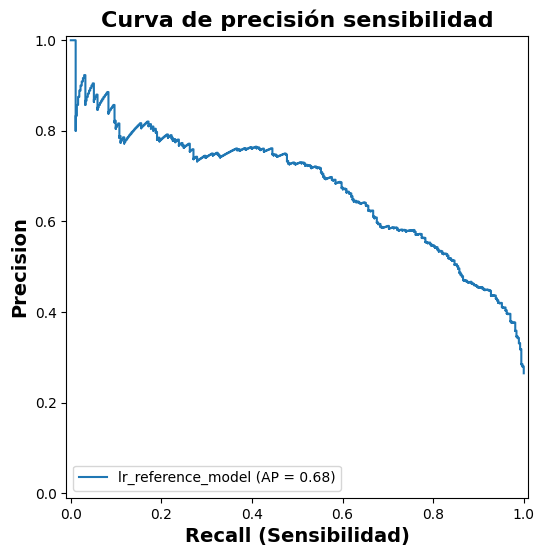

In [14]:
fig, ax = plt.subplots(figsize = (10,6))


PrecisionRecallDisplay.from_estimator(lr_reference_model, X_test, y_test, ax = ax, name='lr_reference_model')
ax.set_xlabel('Recall (Sensibilidad)', fontsize = 14, fontweight = 'bold')
ax.set_ylabel('Precision', fontsize = 14, fontweight = 'bold')
ax.set_title('Curva de precisión sensibilidad', fontsize = 16, fontweight = 'bold')
plt.show()

#**Evaluar el overfitting del modelo**
* Para esto compararemos los resultados que nos dio al predecir el conjunto de test con respecto a los resultados que obtendremos del conjunto de train

In [15]:
y_pred_train = lr_reference_model.predict(X_train)

resultados_train_lr = classification_report(y_train, y_pred_train)
resultados_test_lr = classification_report(y_test, y_pred)

print(f'Resultados conjunto de entrenamiento:  \n\n {resultados_train_lr} \n\n resultados conjunto de test: \n\n {resultados_test_lr}')

Resultados conjunto de entrenamiento:  

               precision    recall  f1-score   support

           0       0.84      0.90      0.87      4138
           1       0.65      0.53      0.59      1496

    accuracy                           0.80      5634
   macro avg       0.75      0.72      0.73      5634
weighted avg       0.79      0.80      0.79      5634
 

 resultados conjunto de test: 

               precision    recall  f1-score   support

           0       0.86      0.91      0.88      1036
           1       0.69      0.58      0.63       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.76      1409
weighted avg       0.81      0.82      0.82      1409



#**Segundo Modelo Regresión logística con Class_weight**
* Probaré un segundo modelo utilizando el parámetro weighted de regresión logística para que le dé más peso a la clase que aparece menos, para esto debo copiar el Pipeline hecho anteriormente y modificar un parámetro del modelo, se hizo una copia de este en vez de modificar el primer Pipeline para luego poder comparar con otros métodos de balanceo de clases como Smote o NearMiss

In [16]:
lr_balanceado = clone(pipeline_lr)
lr_balanceado.set_params(model = LogisticRegressionCV(class_weight='balanced'))
lr_balanceado.fit(X_train, y_train)
y_pred_lr_balanceado = lr_balanceado.predict(X_test)
y_pred_proba_lr_balanceado = lr_balanceado.predict_proba(X_test)

#**Métricas para evaluar el modelo**

In [17]:
print(classification_report(y_test, y_pred_lr_balanceado))

              precision    recall  f1-score   support

           0       0.92      0.74      0.82      1036
           1       0.53      0.82      0.64       373

    accuracy                           0.76      1409
   macro avg       0.72      0.78      0.73      1409
weighted avg       0.81      0.76      0.77      1409



#**Comparación de gráficos de Precisión Sensibilidad**

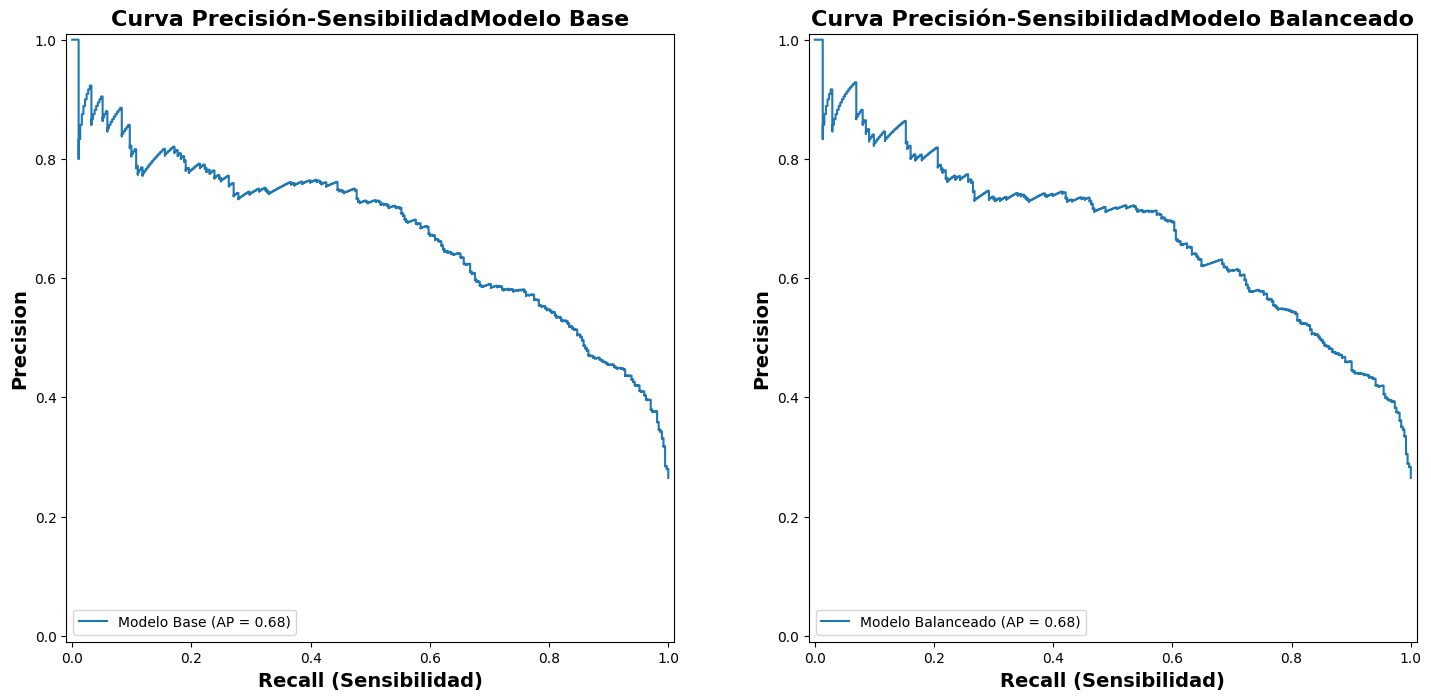

In [18]:
lista_modelos_lr_balanceado = [(lr_reference_model,'Modelo Base'), (lr_balanceado,'Modelo Balanceado')]

graficar_curvas_precision_recall(lista_modelos_lr_balanceado)


#**Modelo utilizando Smote para balancear**
* Aquí crearé un nuevo Pipeline basándome en el original, pero antes de seleccionar el modelo, se agrega una técnica de balanceo llamada SMOTE

In [19]:
lr_smote = ImbPipeline([
    ('Selector', ColumnSelector(lista_seleccionadas)),
    ('scaler', SklearnTransformerWrapper(StandardScaler(), variables=lista_continuas)),
    ('encoding', OneHotEncoder(variables=lista_strings,drop_last=True, top_categories = None)),
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegressionCV())])

lr_smote.fit(X_train, y_train)
y_pred_lr_smote = lr_smote.predict(X_test)
y_pred_proba_lr_smote = lr_smote.predict_proba(X_test)

#**Métricas del modelo Logistic Regression con SMOTE**

In [20]:
print(classification_report(y_test, y_pred_lr_smote))

              precision    recall  f1-score   support

           0       0.89      0.78      0.83      1036
           1       0.54      0.72      0.62       373

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.76      0.77      1409



##**Comparar gráfico de precisión Sensibilidad para Modelo con balanceo SMOTE**

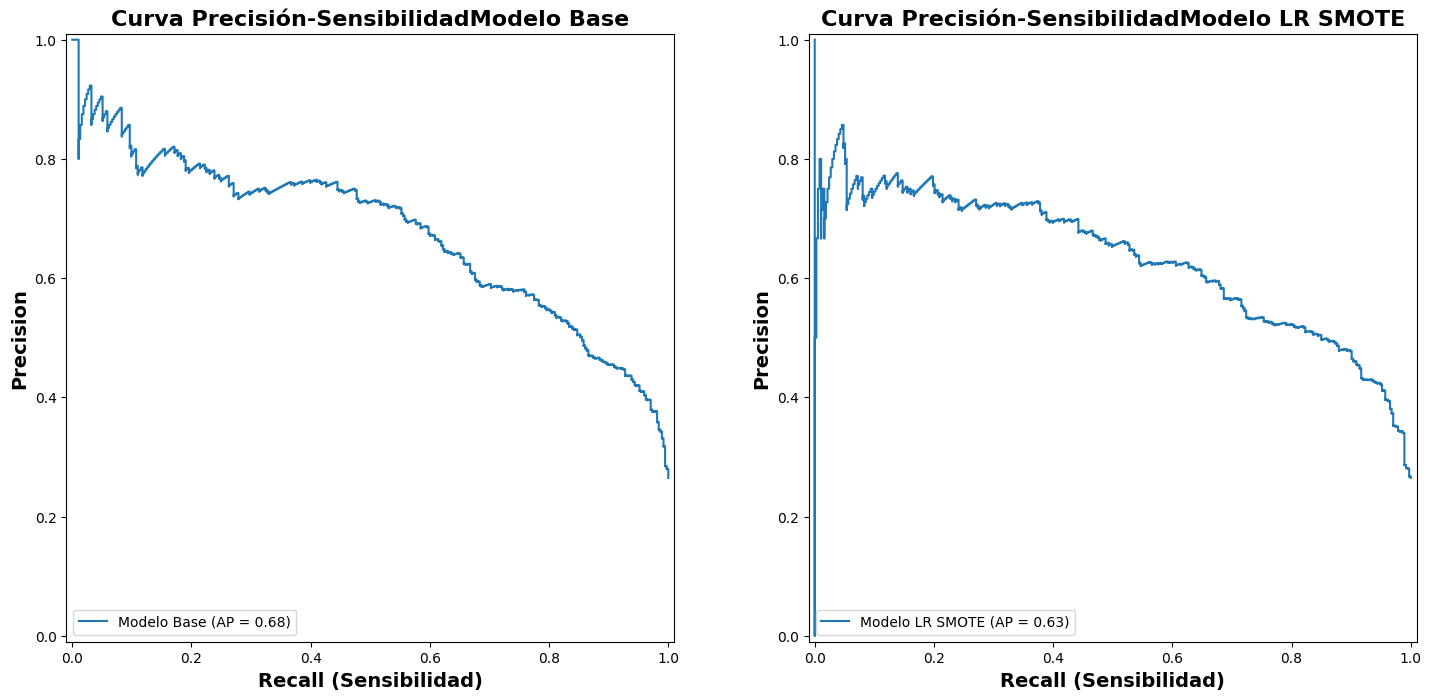

In [21]:
lista_modelos_lr_smote = [(lr_reference_model, 'Modelo Base'), (lr_smote, 'Modelo LR SMOTE')]

graficar_curvas_precision_recall(lista_modelos_lr_smote)

#**Modelo utilizando NearMiss para balancear**
* Ahora se utilizará otra técnica para balancear los datos, también se debe realizar otro Pipeline para procesar estos datos e incluir el balanceador.

In [22]:
lr_near_miss = ImbPipeline([
    ('Selector', ColumnSelector(lista_seleccionadas)),
    ('scaler', SklearnTransformerWrapper(StandardScaler(), variables=lista_continuas)),
    ('encoding', OneHotEncoder(variables=lista_strings,drop_last=True, top_categories = None)),
    ('near_miss', NearMiss(version=3)),
    ('model', LogisticRegressionCV())])

lr_near_miss.fit(X_train, y_train)
y_pred_lr_near_miss = lr_near_miss.predict(X_test)
y_pred_proba_lr_near_miss = lr_near_miss.predict_proba(X_test)

#**Métricas para NearMiss**

In [23]:
print(classification_report(y_test, y_pred_lr_near_miss))

              precision    recall  f1-score   support

           0       0.89      0.82      0.85      1036
           1       0.59      0.72      0.65       373

    accuracy                           0.79      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.81      0.79      0.80      1409



##**Comparación de gráfico Precisión Sensibilidad para Modelo NearMiss**

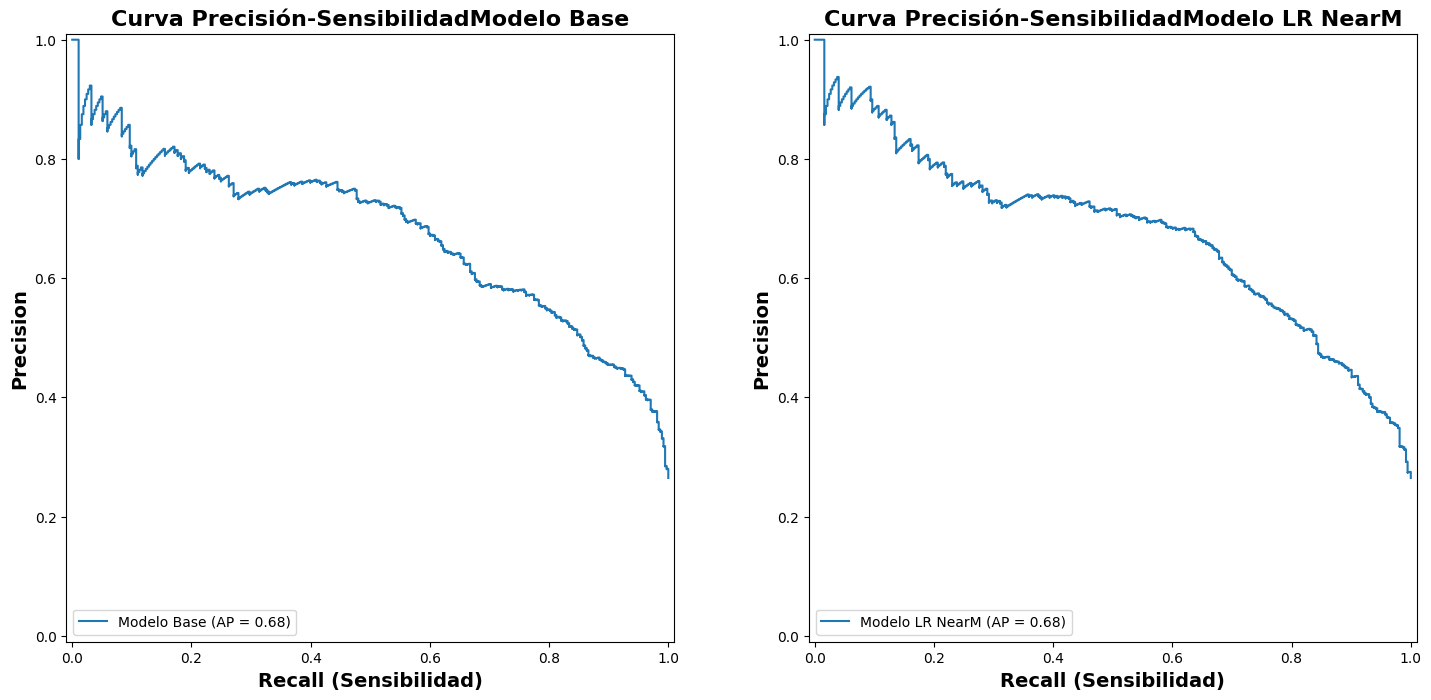

In [24]:
lista_modelos_lr_near_miss = [
    (lr_reference_model,'Modelo Base'), (lr_near_miss,'Modelo LR NearM')]

graficar_curvas_precision_recall(lista_modelos_lr_near_miss)

#**Conclusión de modelos lineales**
* Hasta el momento el mejor modelo es la regresión lineal sin utilizar técnicas de balanceo de datos adicionales a las que aporta el mismo modelo.
* Aplicar distintas técnicas de balance no ha mejorado el modelo, probablemente se deba a que las clases no están tan desbalanceadas y el modelo es capaz de detectar la diferencia entre ellas.

#**Modelos Xgboost**
* Se utilizará un modelo diferente basado en árboles para poder comparar con el baseline

In [27]:
pipeline_no_lineal_ohe = Pipeline([
    ('Selector', ColumnSelector(lista_seleccionadas)),
    ('encoding', OneHotEncoder(variables=lista_strings, drop_last=True, top_categories=None)),
    ('model', XGBClassifier())
  ])

pipeline_no_lineal_le = Pipeline([
    ('Selector', ColumnSelector(lista_seleccionadas)),
    ('encoding', OrdinalEncoder(encoding_method='ordered', variables=lista_strings)),
    ('model', XGBClassifier())
])

##**Definir una función con Optuna para optimizar hiperparámetros**
* Se define una función que permita optimizar hiperparámetros para obtener una idea inicial de qué tan bueno es el modelo

###**Pipeline para modelos no lineales**
* En este caso no es necesario utilizar un escalamiento de las variables ya que los modelos de árboles no son sensibles a la magnitud de las variables continuas, además probaré utilizando LabelEncoder y OneHotEncoder para ver cual da mejores resultados

##**Modelo Xgboost con OneHotEncoder**

In [28]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

def objective_ohe(trial):
  params = {
      "max_depth": trial.suggest_int("max_depth", 2, 20),
      "n_estimators": trial.suggest_int("n_estimators", 100, 2000),
      "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
      "subsample": trial.suggest_float("subsample", 0.6, 1.0),
      "colsample_bytree": trial.suggest_float("colsample_bytree",0.3,1.0)
  }

  pipeline = Pipeline([
    ('Selector', ColumnSelector(lista_seleccionadas)),
    ('encoding', OneHotEncoder(variables=lista_strings, drop_last=True, top_categories=None)),
    ('model', XGBClassifier(**params, scale_pos_weight = scale_pos_weight, eval_metric = "logloss", random_state=42))
  ])

  cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
  scorer = make_scorer(f1_score, pos_label=1)

  scores = cross_val_score(pipeline, X_train, y_train, cv = cv, scoring=scorer)

  return scores.mean()

optuna.logging.set_verbosity(optuna.logging.WARNING)
study_ohe = optuna.create_study(direction='maximize')
study_ohe.optimize(objective_ohe, n_trials=30)
print(study_ohe.best_params)

{'max_depth': 2, 'n_estimators': 423, 'learning_rate': 0.07727735886343796, 'subsample': 0.7710175696572549, 'colsample_bytree': 0.6113357764611607}


##**Entrenar el modelo XGBoostClassifier usando ordinal Encoder**

In [29]:
xgb_optuna_ohe =  clone(pipeline_no_lineal_ohe)
xgb_optuna_ohe.set_params(model=XGBClassifier (random_state=42, eval_metric="logloss", **study_ohe.best_params, n_jobs=-1))
xgb_optuna_ohe.fit(X_train, y_train)
y_pred_xgb_ohe = xgb_optuna_ohe.predict(X_test)

##**Metricas para evaluar el modelo**

In [30]:
print(classification_report(y_test, y_pred_xgb_ohe))

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1036
           1       0.67      0.55      0.60       373

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



##**Curva Precisión - Recall para Xgboost con One Hot Encoder**

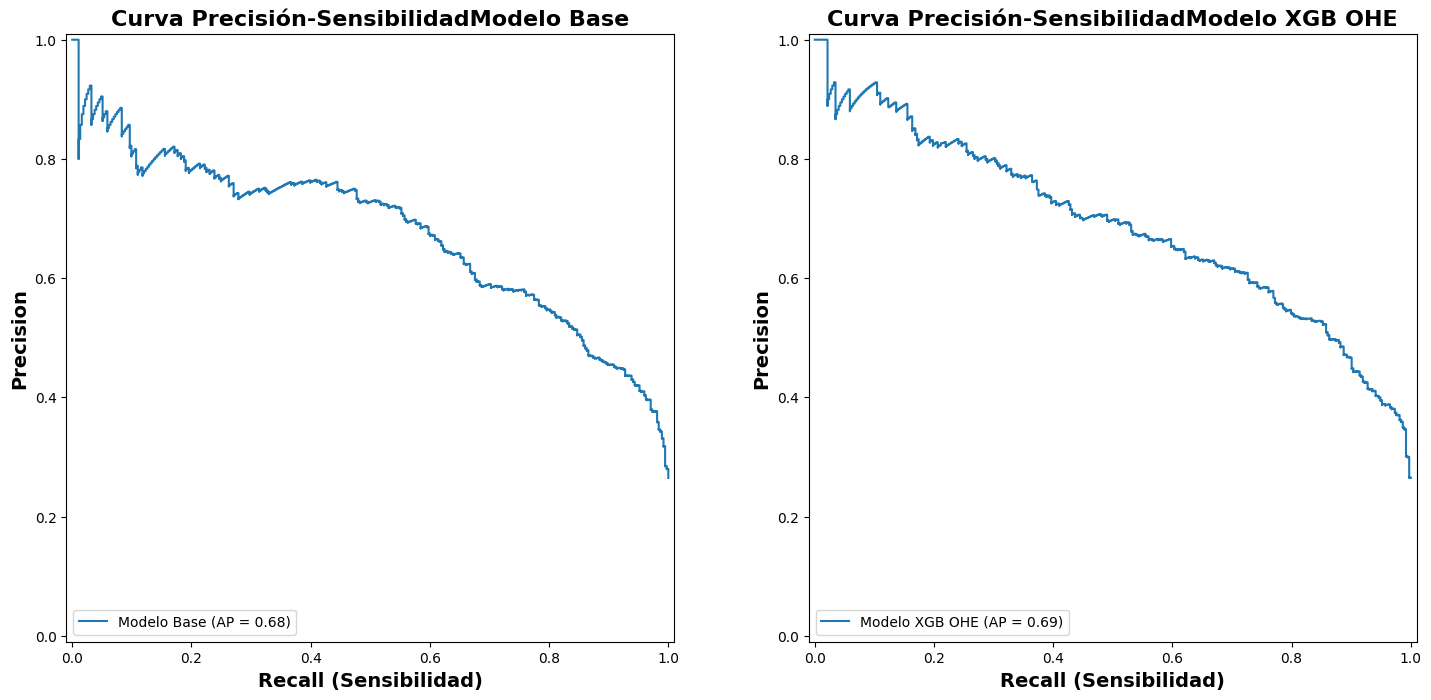

In [34]:
lista_modelos_xgb_ohe = [
    (lr_reference_model, "Modelo Base"), (xgb_optuna_ohe, "Modelo XGB OHE")]

graficar_curvas_precision_recall(lista_modelos_xgb_ohe)

##**Modelo Xgboot con Label Encoder**

In [31]:
def objective_le(trial):
  params = {
      "max_depth": trial.suggest_int("max_depth", 3, 10),
      "n_estimators": trial.suggest_int("n_estimators",100, 2000),
      "learning_rate": trial.suggest_float("learning_rate",0.01, 0.3, log=True),
      "subsample": trial.suggest_float("subsample", 0.6, 1.0),
      "colsample_bytree": trial.suggest_float("colsample_bytree", 0.3, 1.0)
  }

  pipeline = Pipeline([
    ('Selector', ColumnSelector(lista_seleccionadas)),
    ('encoding', OrdinalEncoder(variables=lista_strings, encoding_method="ordered")),
    ('model', XGBClassifier(**params, eval_metric = "logloss", random_state=42, scale_pos_weight= scale_pos_weight))
  ])

  cv = StratifiedKFold(n_splits=5, shuffle = True, random_state = 42)
  scorer = make_scorer(f1_score, pos_label=1)

  scores = cross_val_score(pipeline, X_train, y_train, cv = cv, scoring = scorer)
  return scores.mean()


study_le = optuna.create_study(direction="maximize")
study_le.optimize(objective_le, n_trials=30)
print(study_le.best_params)



{'max_depth': 3, 'n_estimators': 267, 'learning_rate': 0.06303546539080074, 'subsample': 0.8319900352255585, 'colsample_bytree': 0.4781184194638426}


##**Entrenar el modelo usando Label Encoder**

In [32]:
xgb_optuna_le = clone(pipeline_no_lineal_le)
xgb_optuna_le.set_params(model = XGBClassifier(random_state=42, n_jobs=-1, **study_le.best_params, eval_metric="logloss"))
xgb_optuna_le.fit(X_train, y_train)
y_pred_xgb_le = xgb_optuna_le.predict(X_test)

In [33]:
print(classification_report(y_test, y_pred_xgb_le))

              precision    recall  f1-score   support

           0       0.85      0.91      0.88      1036
           1       0.68      0.55      0.61       373

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



##**Gráfico Precision Recall XGBoost Ordinal Encoder**

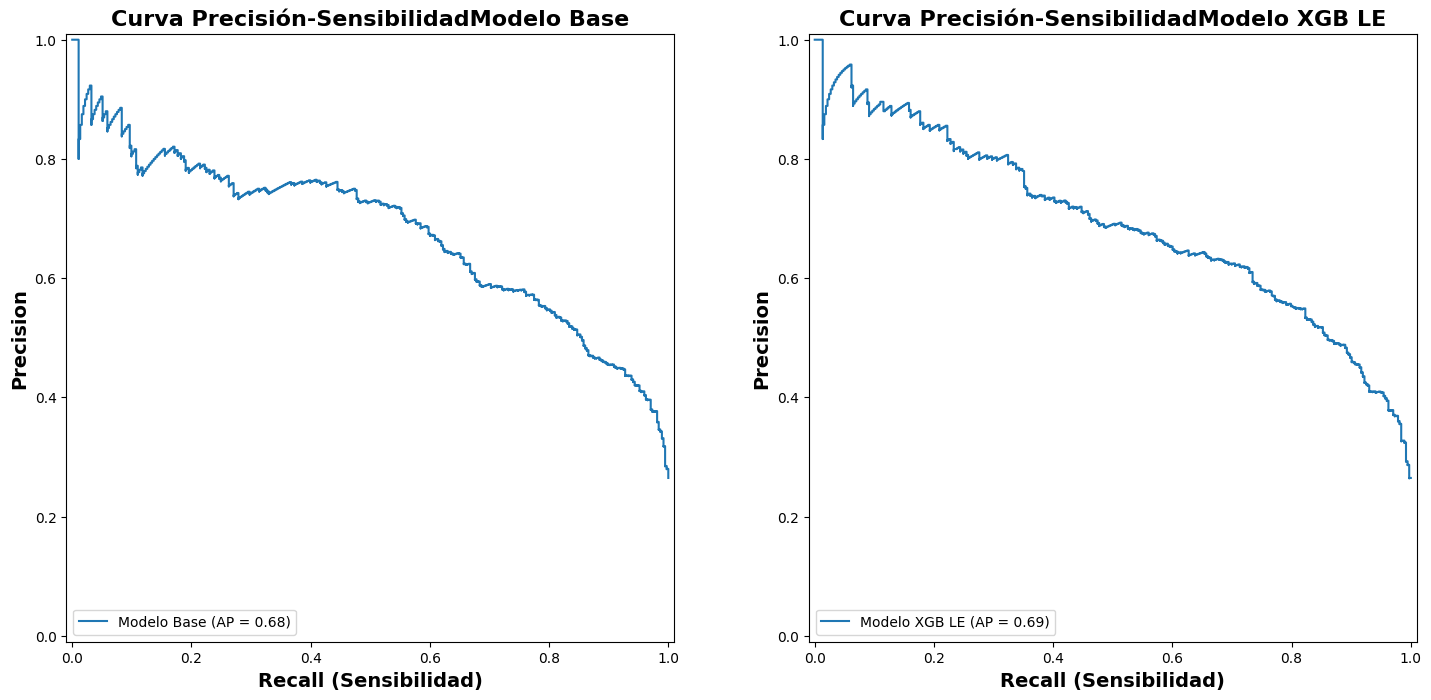

In [35]:
lista_modelos_xgb_le = [
    (lr_reference_model, 'Modelo Base'), (xgb_optuna_le, 'Modelo XGB LE')]

graficar_curvas_precision_recall(lista_modelos_xgb_le)

#**Evaluar la importancia de las características para el Baseline Modelo utilizando sus coeficientes**

/tmp/ipykernel_11114/1998222836.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=coeficientes_lr.values,


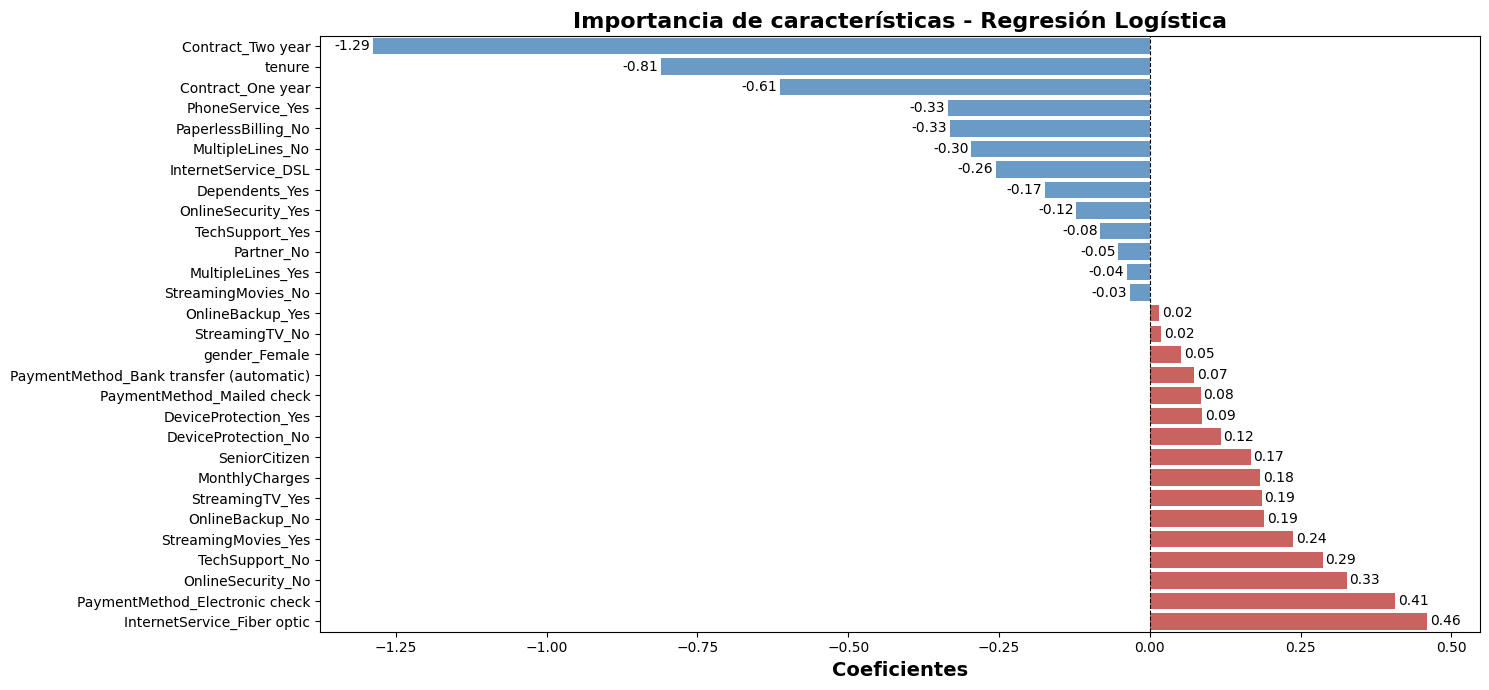

In [72]:
model_lr = lr_reference_model.named_steps['model']
encoder = lr_reference_model.named_steps['encoding']
model_columns = encoder.get_feature_names_out()

coeficientes_lr = pd.Series(model_lr.coef_[0], index= model_columns).sort_values()

fix, ax = plt.subplots(figsize = (15,7))
ax = sns.barplot(x=coeficientes_lr.values,
                 y = coeficientes_lr.index,
                 palette=['#d9534f' if v > 0 else '#5b9bd5' for v in coeficientes_lr.values],
                 ax=ax)
ax.axvline(x=0, color="black", linestyle='--', linewidth=0.8)
ax.set_title('Importancia de características - Regresión Logística', fontsize = 16, fontweight = 'bold')
for container in ax.containers:
  ax.bar_label(container, fmt='{:,.2f}',padding=2)
ax.set_ylabel('')
ax.set_xlabel('Coeficientes', fontsize=14, fontweight= 'bold')
plt.tight_layout()
plt.show()


#**Evaluar la importancia de características para el Baseline Model usando Shap**

##**Gráfico de barras de importancia global de las variables**


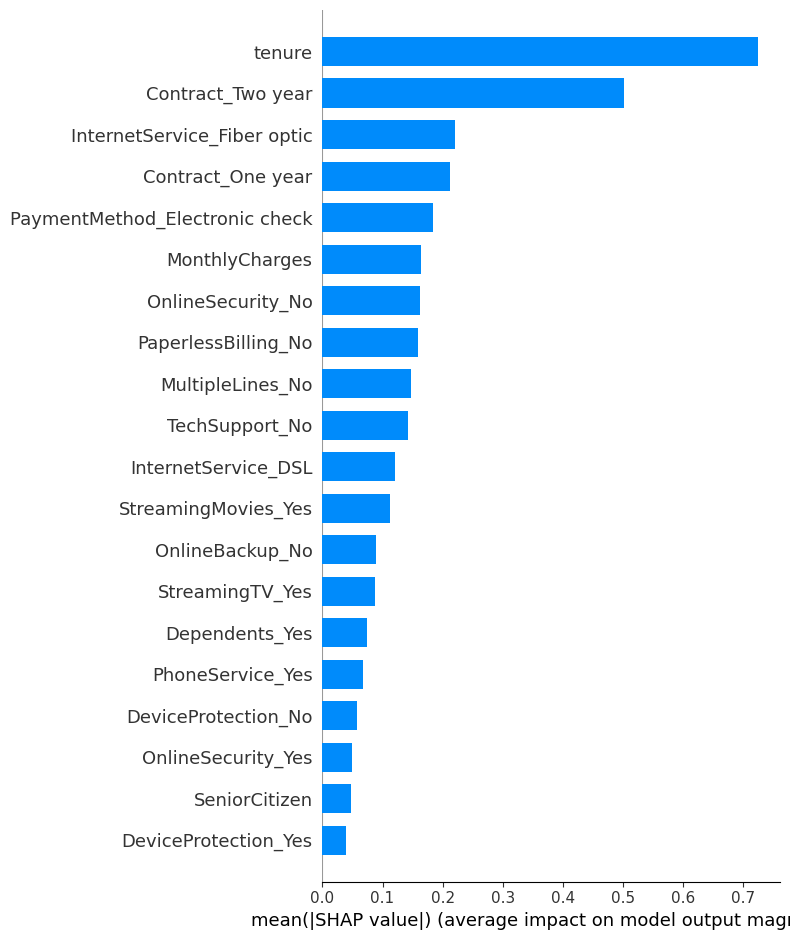

In [36]:
preprocesor = Pipeline(lr_reference_model.steps[:-1])
X_train_transform_reference_model = preprocesor.transform(X_train)

explainer = shap.LinearExplainer(lr_reference_model.named_steps['model'],
                                 X_train_transform_reference_model)

shap_values_lr_base_model = explainer.shap_values(X_train_transform_reference_model)

shap.summary_plot(shap_values_lr_base_model, X_train_transform_reference_model, plot_type='bar', max_display=20  )

##**Beeswarm Plot**

* Muestra todas las predicciones, se puede ver una distribución y dirección
* Al parecer la variable más importante es tenure, a valores bajos de la variable aumenta la probabilidad de que un cliente se vaya, mientras que a valores altos de la variable disminuye la probabilidad que un cliente se vaya.

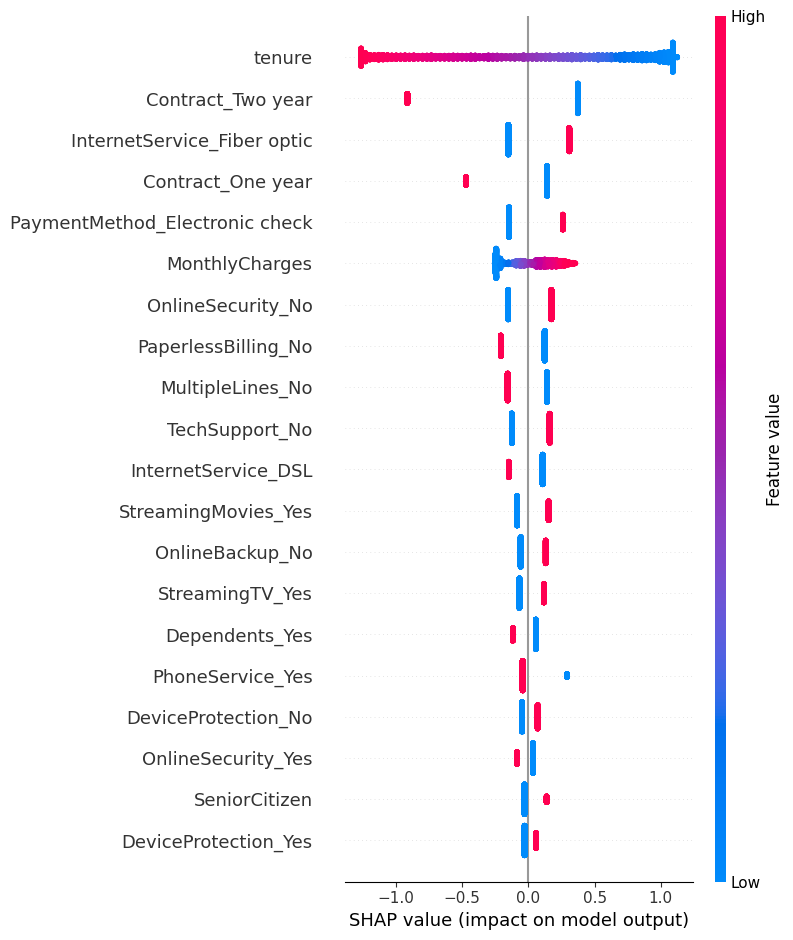

In [37]:
shap.summary_plot(shap_values_lr_base_model, X_train_transform_reference_model, plot_type='dot')

#**Conclusiones**

* El mejor modelo fue el de regresión logística con validación cruzada, ya que es el más simple de todos, demoró menos tiempo en entrenar y obtuvo unos resultados similares a modelos más potentes como XGBoost, probablemente se deba a que este problema podía resolverse como un problema de clasificación lineal, por lo que un modelo basado en árboles no aportaba mucha mejora al ser un modelo no lineal.
* En la curva de Precisión sensibilidad los modelos que presentaron un mejor desempeño fueron los de XGBoost, pero es muy leve la mejor y tuvo un tiempo de entrenamiento más alto debido al ajuste de hiperparámetros y la validación cruzada.
* Al parecer la variable más importante o que más afecta es tenure y también las variables que nos dicen si tiene contrato por uno o dos años.
* Otra variable importante es MonthlyCharges, a mayores valores la tendencia es que los clientes abandonen, tal vez no son tan convenientes los precios.
* Las variables que al parecer aportan menos información al modelo son el género, si tienen servicios de Streaming, ya sean de Tv o películas, el servicio de backup online, si la persona tiene contratada múltiples líneas y si vive o no solo.